# Assignment 05: Raster Data and Environmental Covariates

## BIO597 Spatial Analysis of Biodiversity

This assignment asks you to repeat and extend the raster workflow from Lab 05. You will clip WorldClim rasters to Maine, extract environmental values for selected amphibian occurrences, compare species, and document your predictor choices.

## Deliverable

Submit a completed notebook containing code, raster maps, an occurrence-environment table, and species summaries.

## Learning goals

By the end of this assignment, you should be able to:

* inspect raster metadata and identify alignment problems
* clip global rasters to a study-area polygon
* extract raster values at point locations
* recognize and retain NoData values
* select predictors based on ecological meaning rather than availability alone
* document a reproducible environmental-data workflow

## Data

Use:

* `Amphibians_ME/Amphibians_ME.csv` for occurrence records
* `/home/jovyan/shared-readwrite/bioclim` for WorldClim 2.1 bioclimatic rasters
* `../labs/ME_ShapeFiles/Maine_State_Boundary.shp` for the clipping boundary

The WorldClim files represent 1970–2000 climate normals at 2.5 arc-minute resolution. Variable definitions are available from the [WorldClim bioclimatic variable page](https://www.worldclim.org/data/bioclim.html).

## 1. Import packages

Import `pandas`, `geopandas`, `rioxarray`, and `xarray` using the same abbreviations as Lab 05.
Also import `Path` from the `pathlib` module as we did previously

In [178]:
# Install rioxarray

%pip install rioxarray

Note: you may need to restart the kernel to use updated packages.


In [179]:
# Import the four packages here.

import geopandas as gpd
import pandas as pd
import rioxarray as rxr
import xarray as xr
from pathlib import Path

## 2. Load and combine the Maine boundary

Read `Maine_State_Boundary.shp`. Inspect its CRS and shape, then use `dissolve()` to combine the polygons.

In [180]:
boundary_path = "../labs/ME_ShapeFiles/Maine_State_Boundary.shp"

# Read the boundary.
maine_boundary = gpd.read_file(boundary_path)
# Print its CRS and shape.
print(maine_boundary.shape)
print(maine_boundary.crs)

# Dissolve it to one row.
maine_boundary = maine_boundary.dissolve()
maine_boundary

(6204, 10)
EPSG:4326


,geometry,OBJECTID,LAND,GlobalID,created_us,created_da,last_edite,last_edi_1,Shape__Are,Shape__Len
0,"MULTIPOLYGON (((-70.60685 42.97751, -70.60673 ...",1,y,25ab82ef-ffa7-4098-a01a-01a5c1dfc6fc,Emily.Pettit@maine.gov_maine,2021-08-02,Emily.Pettit@maine.gov_maine,2021-08-02,8.302555e+10,5.736060e+06


## 3. Open annual mean temperature

Open `wc2.1_2.5m_bio_1.tif` with `masked=True`. Store the result as `bio1`.

In [181]:
bioclim_path = Path("/home/jovyan/shared/bioclim")
bio1_path = bioclim_path / "wc2.1_2.5m_bio_1.tif"

bio1 = rxr.open_rasterio(
    bio1_path,
    masked=True,
)

bio1

<xarray.DataArray (band: 1, y: 4320, x: 8640)> Size: 149MB
[37324800 values with dtype=float32]
Coordinates:
  * band         (band) int64 8B 1
  * y            (y) float64 35kB 89.98 89.94 89.9 89.85 ... -89.9 -89.94 -89.98
  * x            (x) float64 69kB -180.0 -179.9 -179.9 ... 179.9 179.9 180.0
    spatial_ref  int64 8B 0
Attributes:
    AREA_OR_POINT:       Area
    STATISTICS_MAXIMUM:  31.166666030884
    STATISTICS_MEAN:     nan
    STATISTICS_MINIMUM:  -54.759166717529
    STATISTICS_STDDEV:   nan
    scale_factor:        1.0
    add_offset:          0.0

## 4. Inspect annual mean temperature metadata

Report:

* dimensions and shape
* data type
* CRS
* resolution
* bounds
* NoData value

Add a brief comment beside each output explaining what it describes.

In [182]:
# Print the requested raster metadata here.
print("Dimensions:", bio1.dims)
print("Shape:", bio1.shape)
print("Data type:", bio1.dtype)
print("CRS:", bio1.rio.crs)
print("Resolution:", bio1.rio.resolution())
print("Bounds:", bio1.rio.bounds())
print("NoData:", bio1.rio.nodata)

Dimensions: ('band', 'y', 'x')
Shape: (1, 4320, 8640)
Data type: float32
CRS: EPSG:4326
Resolution: (0.041666666666666664, -0.041666666666666664)
Bounds: (-180.0, -89.99999999999997, 180.0, 90.0)
NoData: nan


## 5. Clip BIO1 to Maine

Use `rio.clip()` with the dissolved boundary. Set `drop=True` and `from_disk=True`, then remove the one-band dimension with `squeeze()`.

In [183]:
bio1_maine = bio1.rio.clip(
    maine_boundary.geometry,
    maine_boundary.crs,
    drop=True,
    from_disk=True,
)

bio1_maine = bio1_maine.squeeze()

## 6. Compare the global and clipped rasters

Display the shape, bounds, CRS, and resolution of both. State which properties changed and which remained the same.

In [184]:
# Compare global and clipped metadata here.
print("Global shape:", bio1_maine.shape)
print("Maine shape:", bio1_maine.shape)
print("Maine bounds:", bio1_maine.rio.bounds())
print("Maine resolution:", bio1_maine.rio.resolution())

Global shape: (109, 101)
Maine shape: (109, 101)
Maine bounds: (-71.125, 42.95833333333333, -66.91666666666667, 47.5)
Maine resolution: (0.04166666666666671, -0.041666666666666664)


**Your comparison:** Array dimensions changed from a global (very large) to Maine (a lot smaller). The bounds changed from being global to just Maine. The CRS and resolution are the same. 

## 7. Plot annual mean temperature for Maine

Use the DataArray's `.plot()` method and choose an appropriate colormap.

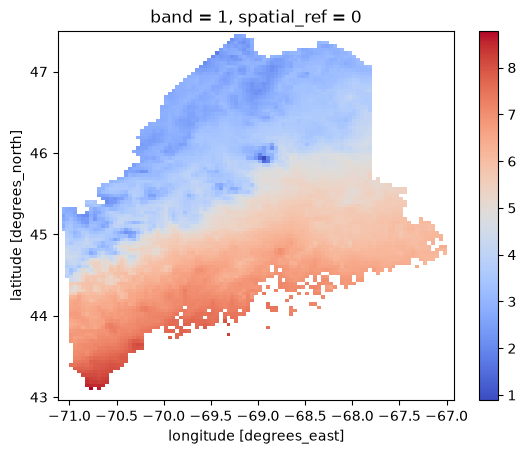

In [185]:
# Plot bio1_maine here.
bio1_maine.plot(cmap="coolwarm")

## 8. Choose three additional bioclimatic variables

Choose three variables from BIO2 through BIO19. Include at least one temperature variable and at least one precipitation variable.

Do not choose variables only because they are available. Give a short biological reason for each choice.

**Variable 1 and justification:** BIO4 (Temperature Seasonality): Wanted to see how temperature shifts over the year. 

**Variable 2 and justification:** BIO11 (Mean Temperature of Coldest Quarter): Wanted to look at the severeity of winter (my field work in Maine is during the winter). 

**Variable 3 and justification:** BIO19 (Precipitation of Coldest Quarter): Wanted to look at total winter snowfall as my fieldwork is on talus slopes.

## 9. Open the first additional raster

Build its filename, open it with `masked=True`, and inspect its CRS, shape, resolution, and bounds.

In [186]:
# Open your first additional raster.
bioclim_path = Path("/home/jovyan/shared/bioclim")

bio4_path = bioclim_path / "wc2.1_2.5m_bio_4.tif"

bio4 = rxr.open_rasterio(
    bio4_path,
    masked=True,
)

bio4

# Inspect its metadata.
print("CRS:", bio4.rio.crs)
print("Resolution:", bio4.rio.resolution())
print("Bounds:", bio4.rio.bounds())
print("NoData:", bio4.rio.nodata)

CRS: EPSG:4326
Resolution: (0.041666666666666664, -0.041666666666666664)
Bounds: (-180.0, -89.99999999999997, 180.0, 90.0)
NoData: nan


## 10. Check alignment with BIO1

Compare CRS, shape, resolution, and bounds. Each comparison should return `True` before you treat the rasters as an aligned stack.

In [187]:
# Compare the first additional raster with bio1.
print("Same CRS:", bio1.rio.crs == bio4.rio.crs)
print("Same shape:", bio1.shape == bio4.shape)
print("Same resolution:", bio1.rio.resolution() == bio4.rio.resolution())
print("Same bounds:", bio1.rio.bounds() == bio4.rio.bounds())

Same CRS: True
Same shape: True
Same resolution: True
Same bounds: True


## 11. Clip and map the first additional raster

Use the same clipping settings as BIO1. Plot the Maine result with an appropriate colormap.

In [188]:
# Clip, squeeze, and plot the first additional raster.
bio4_maine = bio4.rio.clip(
    maine_boundary.geometry,
    maine_boundary.crs,
    drop=True,
    from_disk=True,
)

bio4_maine = bio4_maine.squeeze()

## 12. Repeat for the second additional raster

Open the raster, confirm alignment, clip it to Maine, and plot it. Keep each part of the workflow visible in your code.

In [189]:
# Complete the workflow for the second additional raster.

# Open your second additional raster.

bioclim_path = Path("/home/jovyan/shared/bioclim")

bio11_path = bioclim_path / "wc2.1_2.5m_bio_11.tif"

bio11 = rxr.open_rasterio(
    bio11_path,
    masked=True,
)

bio11

# Inspect its metadata.

print("CRS:", bio11.rio.crs)
print("Resolution:", bio11.rio.resolution())
print("Bounds:", bio11.rio.bounds())
print("NoData:", bio11.rio.nodata)

# Compare the second additional raster with bio1.
print("Same CRS:", bio1.rio.crs == bio11.rio.crs)
print("Same shape:", bio1.shape == bio11.shape)
print("Same resolution:", bio1.rio.resolution() == bio11.rio.resolution())
print("Same bounds:", bio1.rio.bounds() == bio11.rio.bounds())

# Clip, squeeze, and plot the second additional raster.
bio11_maine = bio11.rio.clip(
    maine_boundary.geometry,
    maine_boundary.crs,
    drop=True,
    from_disk=True,
)

bio11_maine = bio11_maine.squeeze()


CRS: EPSG:4326
Resolution: (0.041666666666666664, -0.041666666666666664)
Bounds: (-180.0, -89.99999999999997, 180.0, 90.0)
NoData: nan
Same CRS: True
Same shape: True
Same resolution: True
Same bounds: True


## 13. Repeat for the third additional raster

Open the raster, confirm alignment, clip it to Maine, and plot it.

In [190]:
# Complete the workflow for the third additional raster.

# Open your third additional raster.

bioclim_path = Path("/home/jovyan/shared/bioclim")

bio19_path = bioclim_path / "wc2.1_2.5m_bio_19.tif"

bio19 = rxr.open_rasterio(
    bio19_path,
    masked=True,
)

bio19

# Inspect its metadata.
print("CRS:", bio19.rio.crs)
print("Resolution:", bio19.rio.resolution())
print("Bounds:", bio19.rio.bounds())
print("NoData:", bio19.rio.nodata)

# Compare the third additional raster with bio1.
print("Same CRS:", bio1.rio.crs == bio19.rio.crs)
print("Same shape:", bio1.shape == bio19.shape)
print("Same resolution:", bio1.rio.resolution() == bio19.rio.resolution())
print("Same bounds:", bio1.rio.bounds() == bio19.rio.bounds())

# Clip, squeeze, and plot the third additional raster.
bio19_maine = bio19.rio.clip(
    maine_boundary.geometry,
    maine_boundary.crs,
    drop=True,
    from_disk=True,
)

bio19_maine = bio19_maine.squeeze()

# Confirming the clipped rasters are aligned
print(bio1_maine.shape)
print(bio4_maine.shape)
print(bio11_maine.shape)
print(bio19_maine.shape)

CRS: EPSG:4326
Resolution: (0.041666666666666664, -0.041666666666666664)
Bounds: (-180.0, -89.99999999999997, 180.0, 90.0)
NoData: nan
Same CRS: True
Same shape: True
Same resolution: True
Same bounds: True
(109, 101)
(109, 101)
(109, 101)
(109, 101)


## 14. Load the amphibian records

Read the tab-delimited occurrence file. Keep `gbifID`, `species`, longitude, latitude, and year.

In [191]:
amphibians = gpd.read_file(
    "../assignments/Amphibians_ME/Amphibians_ME.csv",
    x_possible_names="decimalLongitude",
    y_possible_names="decimalLatitude",
).set_crs("EPSG:4326")

print(amphibians.shape)

# Keep the five requested columns.
columns_to_keep = [
    "gbifID",
    "species",
    "decimalLongitude",
    "decimalLatitude",
    "year",
]

amphibians = amphibians[columns_to_keep]

amphibians.head()

(25972, 51)


,gbifID,species,decimalLongitude,decimalLatitude,year
0,6520738729,Lithobates catesbeianus,-68.660278,44.902551,2026
1,6520735611,Aquarana clamitans,-69.649014,44.735713,2026
2,6520729466,Boreorana sylvatica,-69.889241,44.798325,2026
3,6520721493,Lithobates palustris,-68.636788,44.860466,2022
4,6520718655,Lithobates pipiens,-68.788851,44.990948,2026


## 15. Prepare the occurrence coordinates

Convert longitude and latitude to numeric columns. Remove records missing species or coordinates.

In [192]:
# Convert both coordinate columns with pd.to_numeric().
coordinate_cols = ['decimalLongitude', 'decimalLatitude']
amphibians[coordinate_cols] = amphibians[coordinate_cols].apply(pd.to_numeric, errors='coerce')
# Drop rows missing species, longitude, or latitude.
amphibians = amphibians[amphibians["species"] != ""]
amphibians = amphibians[amphibians["decimalLongitude"] != ""]
amphibians = amphibians[amphibians["decimalLatitude"] != ""]

amphibians.shape

(25586, 5)

## 16. Choose three amphibian species

Inspect the species counts, then choose three species with enough records for comparison.

In [193]:
amphibians["species"].value_counts().head(20)

species
Aquarana clamitans            2966
Plethodon cinereus            2864
Pseudacris crucifer           2801
Anaxyrus americanus           2800
Boreorana sylvatica           2794
Ambystoma maculatum           2511
Lithobates catesbeianus       2302
Lithobates palustris          1626
Dryophytes versicolor         1411
Notophthalmus viridescens     1029
Lithobates pipiens             561
Eurycea bislineata             516
Hemidactylium scutatum         334
Ambystoma laterale             322
Desmognathus fuscus            215
Aquarana septentrionalis       198
Gyrinophilus porphyriticus     134
Aquarana catesbeiana            81
Rana arvalis                    54
Ambystoma jeffersonianum        37
Name: count, dtype: int64

**Species 1:** Lithobates pipiens

**Species 2:** Eurycea bislineata 

**Species 3:** Hemidactylium scutatum

In [211]:
selected_species = [
    "Lithobates pipiens",
    "Eurycea bislineata",
    "Hemidactylium scutatum",
]

# Filter the occurrence table with .isin(selected_species).
selected_amphibians = amphibians[amphibians["species"].isin(selected_species)]
selected_amphibians.shape


(1411, 5)

## 17. Create an occurrence GeoDataFrame

Use longitude and latitude to create point geometry. Assign `EPSG:4326`.

In [212]:
# Create selected_amphibians_gdf here.

selected_amphibians_gdf = gpd.GeoDataFrame(
  selected_amphibians, geometry=gpd.points_from_xy(selected_amphibians["decimalLongitude"], selected_amphibians["decimalLatitude"]), crs="EPSG:4326"
)

selected_amphibians_gdf.shape

(1411, 6)

## 18. Confirm coordinate systems

Print the occurrence CRS and raster CRS. Explain what must be true before extracting raster values.

In [213]:
# Print both coordinate systems.
print(selected_amphibians_gdf.crs)
print(bio1_maine.rio.crs)

EPSG:4326
EPSG:4326


**Your explanation:** The occurrence CRS and raster CRS must be the same. 

## 19. Prepare coordinates for extraction

Create `xarray.DataArray` objects called `point_x` and `point_y`. Use one dimension named `record`.

In [214]:
# Create point_x from point longitude.
point_x = xr.DataArray(
    selected_amphibians_gdf .geometry.x.to_numpy(),
    dims="record",
)

# Create point_y from point latitude.
point_y = xr.DataArray(
    selected_amphibians_gdf .geometry.y.to_numpy(),
    dims="record",
)

## 20. Extract annual mean temperature

Use `.sel()` with `x`, `y`, and `method="nearest"`. Add the extracted values to a clearly named column in the occurrence GeoDataFrame.

In [215]:
bio1_values = bio1_maine.sel(
    x=point_x,
    y=point_y,
    method="nearest",
)

# Add the values to selected_amphibians_gdf.

selected_amphibians_gdf["bio1_mean_temp_c"] = bio1_values
selected_amphibians_gdf.head()

,gbifID,species,decimalLongitude,decimalLatitude,year,geometry,bio1_mean_temp_c
4,6520718655,Lithobates pipiens,-68.788851,44.990948,2026,POINT (-68.78885 44.99095),6.283834
13,6520635129,Lithobates pipiens,-67.845134,46.222778,2026,POINT (-67.84513 46.22278),4.332334
79,6520016517,Lithobates pipiens,-67.893790,45.973465,2026,POINT (-67.89379 45.97346),4.692000
143,6519515940,Lithobates pipiens,-68.765251,44.823985,2026,POINT (-68.76525 44.82398),7.003333
321,6518356678,Lithobates pipiens,-68.806008,44.930442,2026,POINT (-68.80601 44.93044),6.328500


## 21. Inspect missing extracted values

Count missing BIO1 values. Explain why coastal occurrences may be assigned NoData even when the coordinates are valid.

In [216]:
# Count missing extracted BIO1 values.
selected_amphibians_gdf["bio1_mean_temp_c"].isna().value_counts()
selected_amphibians_gdf.shape


(1411, 7)

**Your explanation:** Because Bioclim is terrestrial. 

## 22. Extract the three additional variables

Use the same `point_x` and `point_y` arrays. Add one clearly named column for each variable. The column names should include units where practical.

In [217]:
# Extract values from the first additional clipped raster.

bio4_values = bio4_maine.sel(
    x=point_x, 
    y=point_y, 
    method="nearest")

selected_amphibians_gdf["bio4_temp_season_c"] = bio4_values

# Add the values to selected_amphibians_gdf.

selected_amphibians_gdf["bio4_temp_season_c"].isna().value_counts()
selected_amphibians_gdf.shape






(1411, 8)

In [218]:
# Extract values from the second additional clipped raster.

bio11_values = bio11_maine.sel(
    x=point_x, 
    y=point_y, 
    method="nearest")

selected_amphibians_gdf["bio11_mean_temp_coldest_c"] = bio11_values

# Add the values to selected_amphibians_gdf.

selected_amphibians_gdf["bio11_mean_temp_coldest_c"].isna().value_counts()
selected_amphibians_gdf.shape


(1411, 9)

In [219]:
# Extract values from the third additional clipped raster.

bio19_values = bio19_maine.sel(x=point_x, y=point_y, method="nearest")

selected_amphibians_gdf["bio19_precip_coldest_mm"] = bio19_values

# Add the values to selected_amphibians_gdf.

selected_amphibians_gdf["bio19_precip_coldest_mm"].isna().value_counts()
selected_amphibians_gdf.shape


(1411, 10)

## 23. Create the occurrence-environment table

Remove the geometry column and display the first five rows. Confirm that the table contains species, coordinates, year, and four environmental variables.

In [220]:
# Create and display occurrence_environment.

occurrence_environment = selected_amphibians_gdf.drop(columns="geometry")

occurrence_environment.head()

,gbifID,species,decimalLongitude,decimalLatitude,year,bio1_mean_temp_c,bio4_temp_season_c,bio11_mean_temp_coldest_c,bio19_precip_coldest_mm
4,6520718655,Lithobates pipiens,-68.788851,44.990948,2026,6.283834,1025.211548,-6.816000,244.0
13,6520635129,Lithobates pipiens,-67.845134,46.222778,2026,4.332334,1104.598877,-9.975333,236.0
79,6520016517,Lithobates pipiens,-67.893790,45.973465,2026,4.692000,1082.072388,-9.195333,243.0
143,6519515940,Lithobates pipiens,-68.765251,44.823985,2026,7.003333,1028.046509,-6.188000,257.0
321,6518356678,Lithobates pipiens,-68.806008,44.930442,2026,6.328500,1025.414795,-6.774667,246.0


## 24. Summarize environmental values by species

For each selected species, calculate:

* number of records
* mean of each environmental variable
* standard deviation of each environmental variable

In [221]:
# Calculate species-level summaries here.

predictor_columns = [
    "bio1_mean_temp_c",
    "bio4_temp_season_c",
    "bio11_mean_temp_coldest_c",
    "bio19_precip_coldest_mm",
]

for species, samples in occurrence_environment.groupby("species"):
    print(species, len(samples), "\n", samples[predictor_columns].mean())
    print(species, len(samples), "\n", samples[predictor_columns].std())



Eurycea bislineata 516 
 bio1_mean_temp_c                5.755532
bio4_temp_season_c           1019.554600
bio11_mean_temp_coldest_c      -7.249449
bio19_precip_coldest_mm       259.115619
dtype: float64
Eurycea bislineata 516 
 bio1_mean_temp_c              1.541028
bio4_temp_season_c           46.962377
bio11_mean_temp_coldest_c     2.091044
bio19_precip_coldest_mm      29.873324
dtype: float64
Hemidactylium scutatum 334 
 bio1_mean_temp_c               6.753903
bio4_temp_season_c           993.309804
bio11_mean_temp_coldest_c     -5.907006
bio19_precip_coldest_mm      270.156051
dtype: float64
Hemidactylium scutatum 334 
 bio1_mean_temp_c              0.523189
bio4_temp_season_c           43.080168
bio11_mean_temp_coldest_c     1.094972
bio19_precip_coldest_mm      39.640693
dtype: float64
Lithobates pipiens 561 
 bio1_mean_temp_c                5.841830
bio4_temp_season_c           1038.234471
bio11_mean_temp_coldest_c      -7.453274
bio19_precip_coldest_mm       246.154122
dtype: 

## 25. Check relationships among predictors

Create a correlation table for your four environmental variables. Identify any pair with a strong relationship.

In [223]:
# Select the four predictor columns and calculate .corr().

occurrence_environment[predictor_columns].corr().round(2)

,bio1_mean_temp_c,bio4_temp_season_c,bio11_mean_temp_coldest_c,bio19_precip_coldest_mm
bio1_mean_temp_c,1.00,-0.82,0.98,0.52
bio4_temp_season_c,-0.82,1.00,-0.93,-0.80
bio11_mean_temp_coldest_c,0.98,-0.93,1.00,0.64
bio19_precip_coldest_mm,0.52,-0.80,0.64,1.00


**Interpretation:** Which predictors contain similar information? Would you retain all of them in the same model? Explain your reasoning.

## 27. Save your occurrence-environment table

Save it as `Assignment05_environmental_values.csv` beside this notebook. Do not include the DataFrame index.

In [225]:
# Save occurrence_environment with .to_csv().

occurrence_environment.to_csv(
    "Assignment05_environmental_values.csv",
    index=False,

)

## Final reflection

Answer each question in two or three sentences.

1. How do raster resolution and occurrence-coordinate uncertainty interact? It would create a mistmatch which would lead to the data becoming inaccurate because the occurence points are not located properly. From what I undestand, the raster resolution has to be the same or more coarse than the positional uncertaintity of their location data. 
2. What environmental variation is lost when all occurrences in one raster cell receive the same value? It would remove things that are localized environmental variation like micro-climates or terrain. By putting all the occurrences in one raster cell, you lost the very fine and specific details. 
3. Which predictor has the strongest biological justification for your selected species? I think it would probably be bio11 because it is the survival limits for amphibians because most amphibians cannot survive the cold. So I think bio11 would be a good indicator if the species can successfully overwinter.
4. Which preprocessing choice is most important to document for reproducibility? I think how you handle the occurrence-coordinate uncertainty and spatial thinning may the most important for reproducibility. I think it's important that other researchers could be able to follow your steps exactly, so that prevents model variations and it also justifies the choice of your raster. 
5. Name one additional environmental predictor you would seek for an amphibian study and explain why. Maybe using bio18 (precipitation of warmest quarter) would be a good environmental predictor for amphibians because that would be focused on the warmest months and this is the optimal time for breeding for most amphibians. It would be 

## Submit your work

Run the notebook from top to bottom. Make sure all raster maps, tables, and written answers are complete. Then commit and push the completed notebook to your class GitHub repository.

```bash
git add docs/assignments/Assignment-05-RasterData.ipynb
git commit -m "Complete raster data assignment"
git push
```